# House Price Prediction in R (Ridge, Lasso, Random Forest, XGBoost + SHAP)

**Dataset:** [House Prices - Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) (Ames, Iowa; 1,460 houses, 79 features, target `SalePrice`).
Add it via **Add Input -> Competition -> House Prices - Advanced Regression Techniques**. Turn **Internet on** (needed once to install `shapviz`).

**Pipeline:** EDA -> domain-aware preprocessing -> 4 models compared by RMSE (on `log1p(SalePrice)`, the competition metric) -> diagnostic plots -> SHAP explanations.

**Leakage note:** the 80/20 split happens first; every imputation value, skewness decision and scaling constant is computed on the training split only.

In [8]:
pkgs <- c("tidyverse", "glmnet", "randomForest", "xgboost", "e1071", "shapviz")
for (p in pkgs) if (!requireNamespace(p, quietly = TRUE)) install.packages(p)
suppressPackageStartupMessages({
  library(tidyverse); library(glmnet); library(randomForest)
  library(xgboost); library(e1071); library(shapviz)
})
set.seed(42)
options(repr.plot.width = 9, repr.plot.height = 5)

In [9]:
path <- "/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv"
stopifnot("train.csv not found - did you Add Input?" = file.exists(path))
raw <- read.csv(path, stringsAsFactors = FALSE)
dim(raw)   # expect 1460 x 81

[1] 1460   81

## 1. Exploratory Data Analysis

Skewness - original: 1.88 | log1p: 0.12 


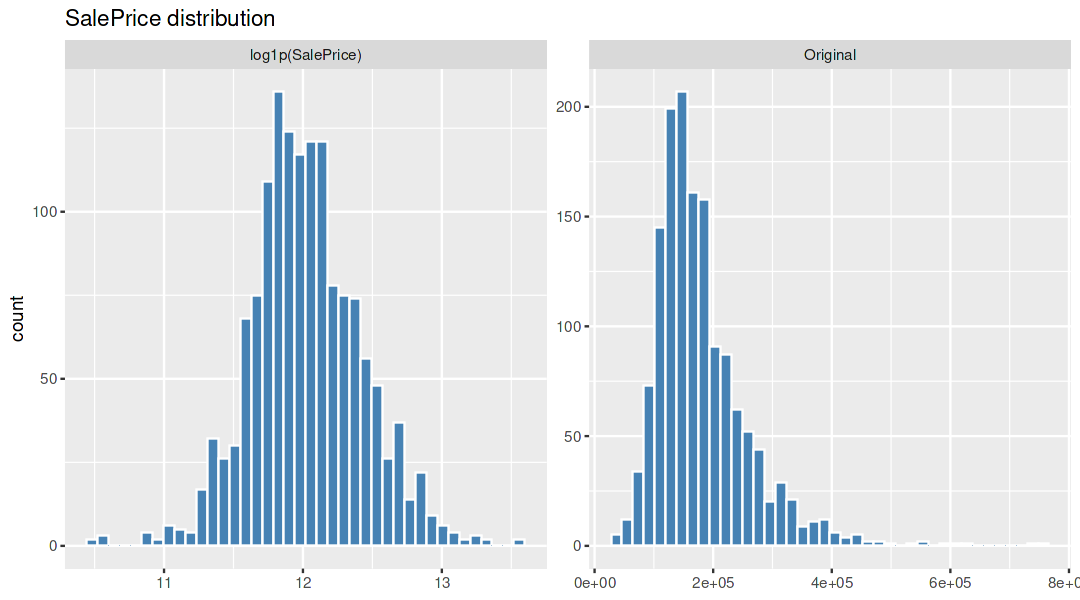

In [10]:
# SalePrice: original vs log-transformed
raw %>%
  transmute(Original = SalePrice, `log1p(SalePrice)` = log1p(SalePrice)) %>%
  pivot_longer(everything()) %>%
  ggplot(aes(value)) +
  geom_histogram(bins = 40, fill = "steelblue", colour = "white") +
  facet_wrap(~name, scales = "free") +
  labs(title = "SalePrice distribution", x = NULL)

cat("Skewness - original:", round(skewness(raw$SalePrice), 2),
    "| log1p:", round(skewness(log1p(raw$SalePrice)), 2), "\n")

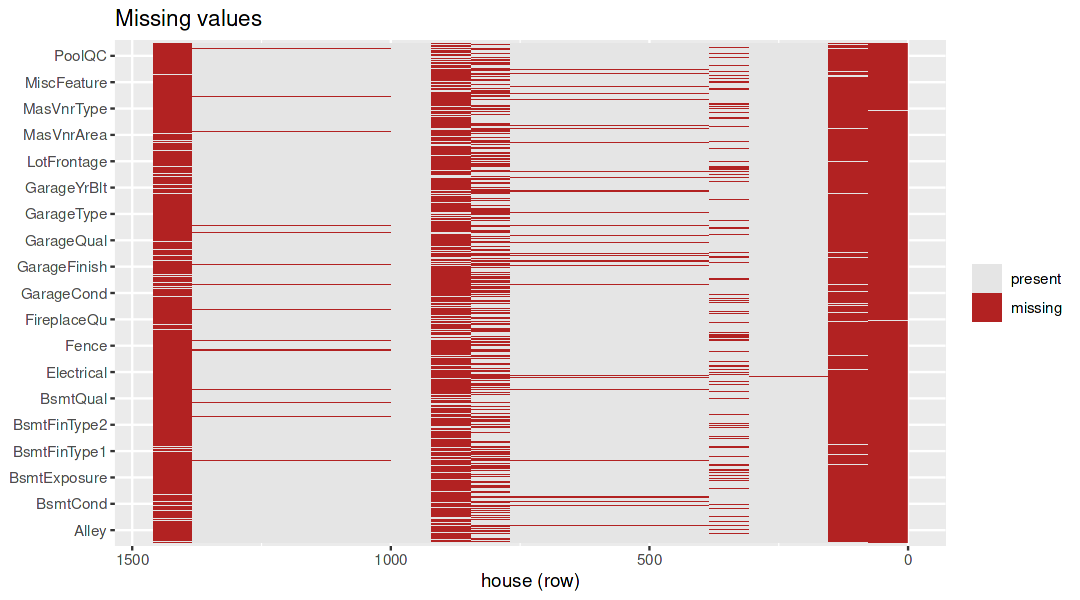

In [11]:
# Missing-value heatmap (only columns that have missing values)
na_cols <- names(which(colSums(is.na(raw)) > 0))
as.data.frame(is.na(raw[, na_cols])) %>%
  mutate(row = row_number()) %>%
  pivot_longer(-row, names_to = "feature", values_to = "missing") %>%
  ggplot(aes(feature, row, fill = missing)) +
  geom_raster() +
  scale_fill_manual(values = c("grey90", "firebrick"), labels = c("present", "missing")) +
  scale_y_reverse() + coord_flip() +
  labs(title = "Missing values", x = NULL, y = "house (row)", fill = NULL)

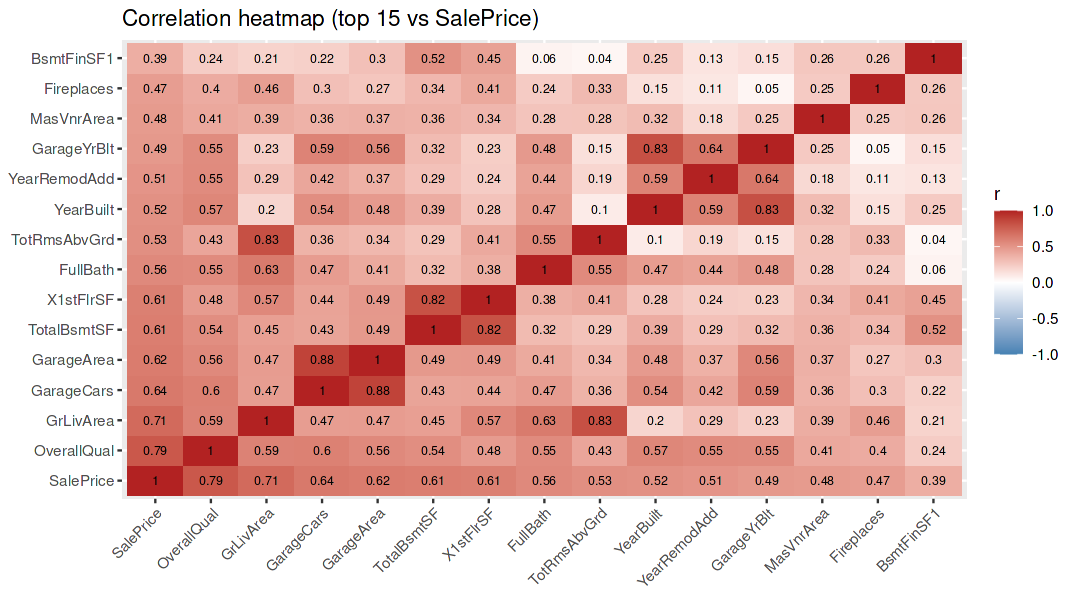

In [12]:
# Correlation heatmap: top 15 numeric features most correlated with SalePrice
num <- raw %>% select(where(is.numeric)) %>% select(-Id)
top <- names(sort(abs(cor(num, use = "pairwise.complete.obs")[, "SalePrice"]), decreasing = TRUE))[1:15]
cor(num[, top], use = "pairwise.complete.obs") %>%
  as.data.frame.table(responseName = "r") %>%
  ggplot(aes(Var1, Var2, fill = r)) +
  geom_tile() +
  geom_text(aes(label = round(r, 2)), size = 2.5) +
  scale_fill_gradient2(low = "steelblue", mid = "white", high = "firebrick", limits = c(-1, 1)) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Correlation heatmap (top 15 vs SalePrice)", x = NULL, y = NULL)

`geom_smooth()` using formula = 'y ~ x'


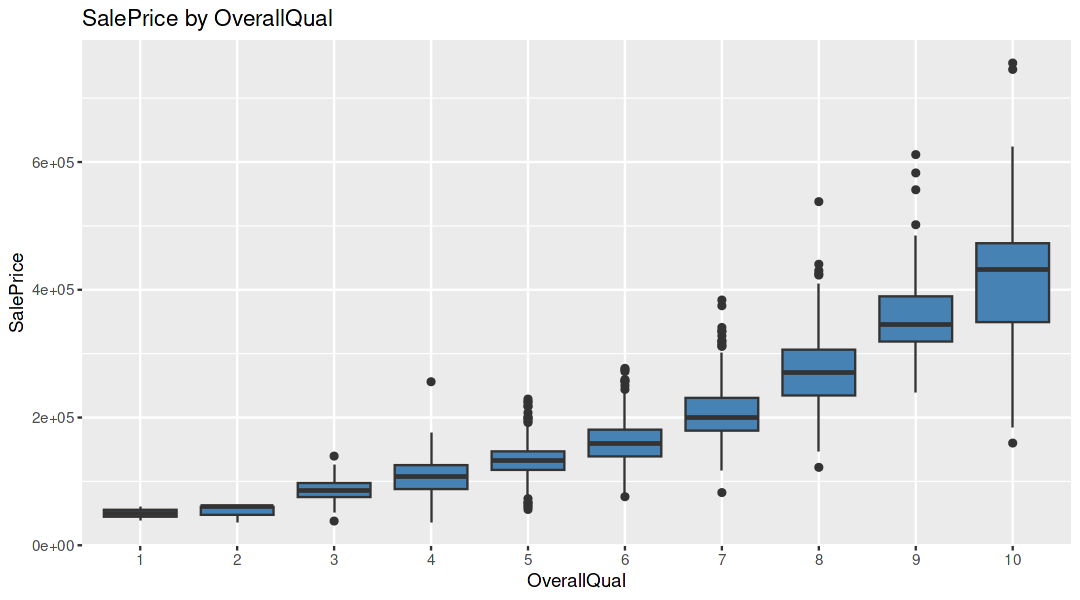

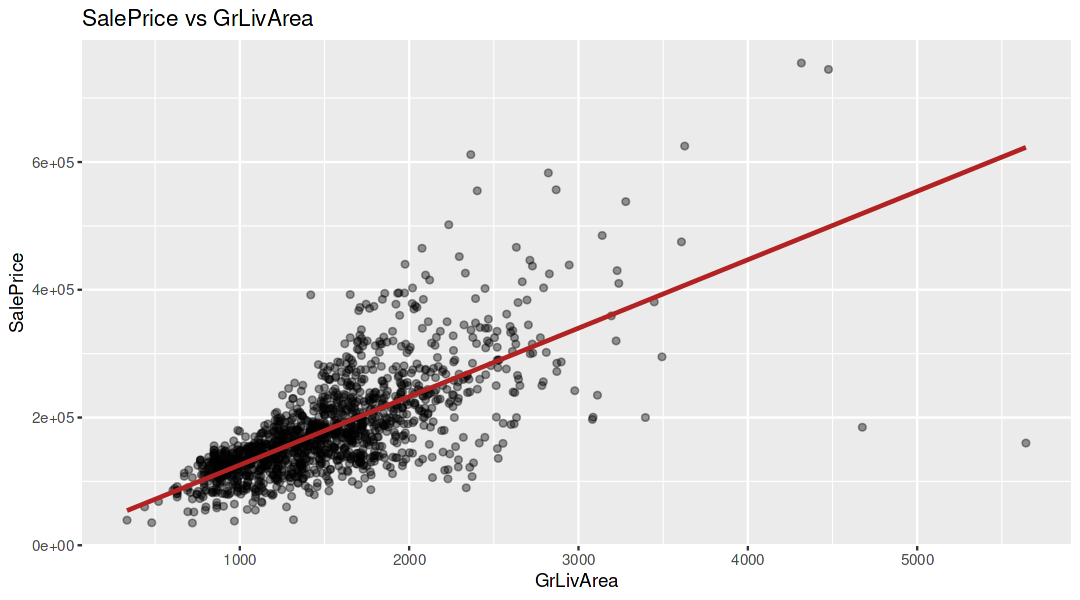

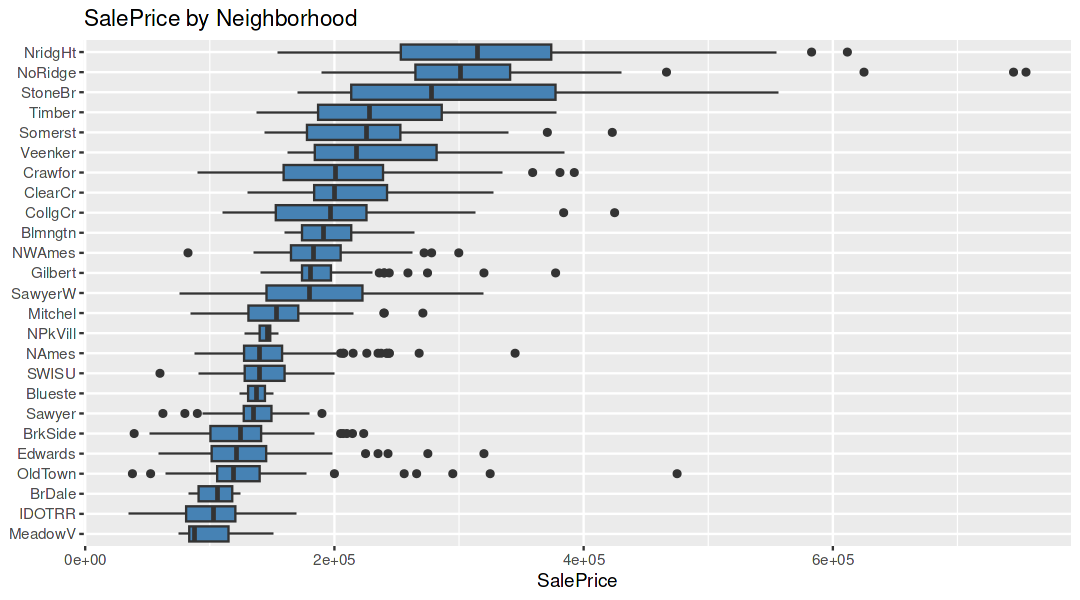

In [13]:
# Key features vs target
print(ggplot(raw, aes(factor(OverallQual), SalePrice)) +
  geom_boxplot(fill = "steelblue") + labs(title = "SalePrice by OverallQual", x = "OverallQual"))

print(ggplot(raw, aes(GrLivArea, SalePrice)) +
  geom_point(alpha = 0.4) + geom_smooth(method = "lm", se = FALSE, colour = "firebrick") +
  labs(title = "SalePrice vs GrLivArea"))

print(ggplot(raw, aes(reorder(Neighborhood, SalePrice, median), SalePrice)) +
  geom_boxplot(fill = "steelblue") + coord_flip() +
  labs(title = "SalePrice by Neighborhood", x = NULL))

## 2. Preprocessing
Steps: train/test split -> domain-aware missing values -> two engineered features -> skewness correction -> one-hot encoding -> scaling (for the linear models).

In [14]:
idx      <- sample(nrow(raw), size = round(0.8 * nrow(raw)))
tr       <- raw[idx, ]
te       <- raw[-idx, ]
y_tr     <- log1p(tr$SalePrice)
y_te     <- log1p(te$SalePrice)
price_te <- te$SalePrice

In [15]:
# Domain-aware fixes (no statistics needed, so safe to apply to both splits).
# In this dataset NA in these columns means "the house has no such feature".
none_cols <- c("Alley", "MasVnrType", "BsmtQual", "BsmtCond", "BsmtExposure",
               "BsmtFinType1", "BsmtFinType2", "FireplaceQu", "GarageType",
               "GarageFinish", "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature")

domain_fill <- function(df) {
  df$Id <- NULL
  df$MSSubClass <- as.character(df$MSSubClass)              # a category stored as a number
  for (col in none_cols) df[[col]][is.na(df[[col]])] <- "None"
  df$MasVnrArea[is.na(df$MasVnrArea)] <- 0
  df$GarageYrBlt <- ifelse(is.na(df$GarageYrBlt), df$YearBuilt, df$GarageYrBlt)
  df$TotalSF  <- df$TotalBsmtSF + df$X1stFlrSF + df$X2ndFlrSF   # engineered
  df$HouseAge <- pmax(df$YrSold - df$YearBuilt, 0)              # engineered
  df$SalePrice <- NULL
  df
}
tr <- domain_fill(tr)
te <- domain_fill(te)

In [16]:
# Remaining gaps: LotFrontage -> median of its neighbourhood; other numeric -> median;
# other categorical -> mode. All values come from the TRAIN split.
num_cols <- names(tr)[sapply(tr, is.numeric)]
cat_cols <- setdiff(names(tr), num_cols)
num_med  <- sapply(tr[num_cols], median, na.rm = TRUE)
cat_mode <- sapply(tr[cat_cols], function(x) names(which.max(table(x))))
lf_hood  <- tapply(tr$LotFrontage, tr$Neighborhood, median, na.rm = TRUE)

generic_fill <- function(df) {
  lf <- as.numeric(lf_hood[df$Neighborhood])
  lf[is.na(lf)] <- num_med[["LotFrontage"]]
  df$LotFrontage <- ifelse(is.na(df$LotFrontage), lf, df$LotFrontage)
  for (col in num_cols) df[[col]][is.na(df[[col]])] <- num_med[[col]]
  for (col in cat_cols) df[[col]][is.na(df[[col]])] <- cat_mode[[col]]
  df
}
tr <- generic_fill(tr)
te <- generic_fill(te)
stopifnot(sum(is.na(tr)) == 0, sum(is.na(te)) == 0)   # check: no missing values remain

In [17]:
# Skewness correction: log1p on numeric features with |skew| > 0.75 (decided on train)
skew   <- sapply(tr[num_cols], skewness)
skewed <- names(which(abs(skew) > 0.75))
tr[skewed] <- log1p(tr[skewed])
te[skewed] <- log1p(te[skewed])
cat(length(skewed), "features log-transformed\n")

21 features log-transformed


In [18]:
# One-hot encode (train + test together only to guarantee identical columns; no target involved)
all_x <- bind_rows(tr, te) %>% mutate(across(all_of(cat_cols), as.factor))
X_all <- model.matrix(~ . - 1, data = all_x)
colnames(X_all) <- make.names(colnames(X_all))
n_tr  <- nrow(tr)
X_tr  <- X_all[seq_len(n_tr), ]
X_te  <- X_all[-seq_len(n_tr), ]

keep <- apply(X_tr, 2, sd) > 0            # drop constant columns
X_tr <- X_tr[, keep]; X_te <- X_te[, keep]

# Scaling with train mean/sd - used by Ridge/Lasso (trees don't need it, and SHAP stays in real units)
ctr   <- colMeans(X_tr); scl <- apply(X_tr, 2, sd)
Xs_tr <- scale(X_tr, ctr, scl)
Xs_te <- scale(X_te, ctr, scl)
dim(X_tr)

[1] 1168  271

## 3. Models
Target is `log1p(SalePrice)`; RMSE on this scale is the Kaggle competition metric. Dollar RMSE is also reported.

In [19]:
rmse  <- function(a, p) sqrt(mean((a - p)^2))
preds <- list()

# Ridge & Lasso (lambda chosen by 10-fold CV)
ridge <- cv.glmnet(Xs_tr, y_tr, alpha = 0)
lasso <- cv.glmnet(Xs_tr, y_tr, alpha = 1)
preds$Ridge <- as.numeric(predict(ridge, Xs_te, s = "lambda.min"))
preds$Lasso <- as.numeric(predict(lasso, Xs_te, s = "lambda.min"))

# Random Forest
rf <- randomForest(x = X_tr, y = y_tr, ntree = 500)
preds$RandomForest <- as.numeric(predict(rf, X_te))

In [20]:
# XGBoost: number of rounds picked by 5-fold CV with early stopping
dtr    <- xgb.DMatrix(X_tr, label = y_tr)
params <- list(objective = "reg:squarederror", eval_metric = "rmse",
               eta = 0.03, max_depth = 3, subsample = 0.7, colsample_bytree = 0.7)
cv     <- xgb.cv(params = params, data = dtr, nrounds = 3000, nfold = 5,
                 early_stopping_rounds = 50, verbose = 0)
best_n <- which.min(cv$evaluation_log$test_rmse_mean)
xgb_model <- xgb.train(params = params, data = dtr, nrounds = best_n)
preds$XGBoost <- as.numeric(predict(xgb_model, X_te))
cat("XGBoost rounds:", best_n, "\n")

XGBoost rounds: 829 


# A tibble: 4 × 3
  Model        RMSE_log RMSE_dollars
  <chr>           <dbl>        <dbl>
1 XGBoost         0.116       28859.
2 Lasso           0.118       28765.
3 Ridge           0.129       33670.
4 RandomForest    0.129       30476.


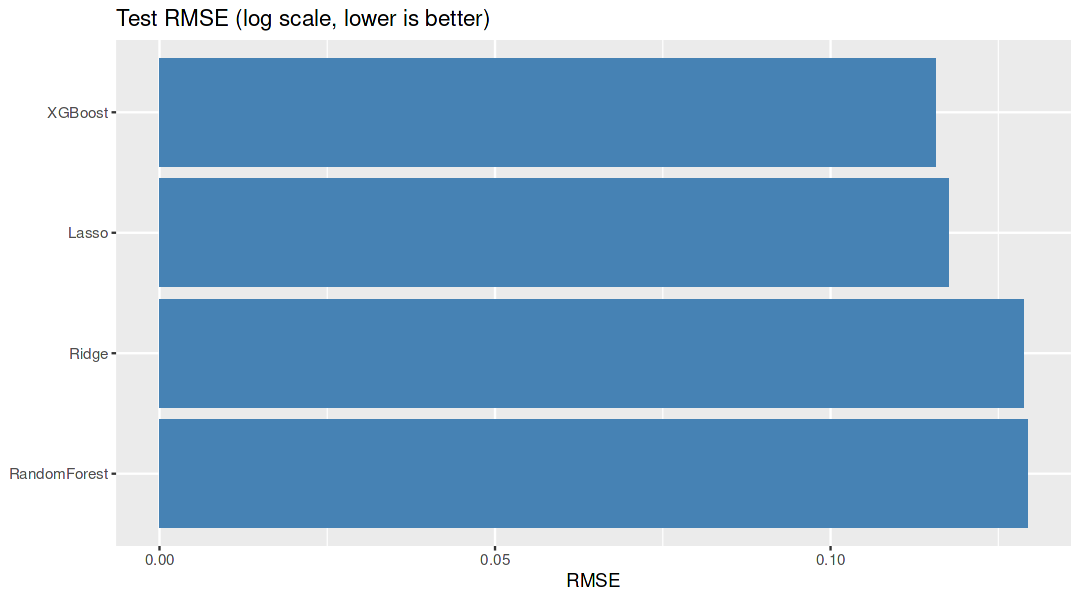

In [21]:
results <- tibble(
  Model        = names(preds),
  RMSE_log     = map_dbl(preds, ~ rmse(y_te, .x)),
  RMSE_dollars = map_dbl(preds, ~ rmse(price_te, expm1(.x)))
) %>% arrange(RMSE_log)
print(results)

ggplot(results, aes(reorder(Model, -RMSE_log), RMSE_log)) +
  geom_col(fill = "steelblue") + coord_flip() +
  labs(title = "Test RMSE (log scale, lower is better)", x = NULL, y = "RMSE")

## 4. Diagnostics (best model by test RMSE)

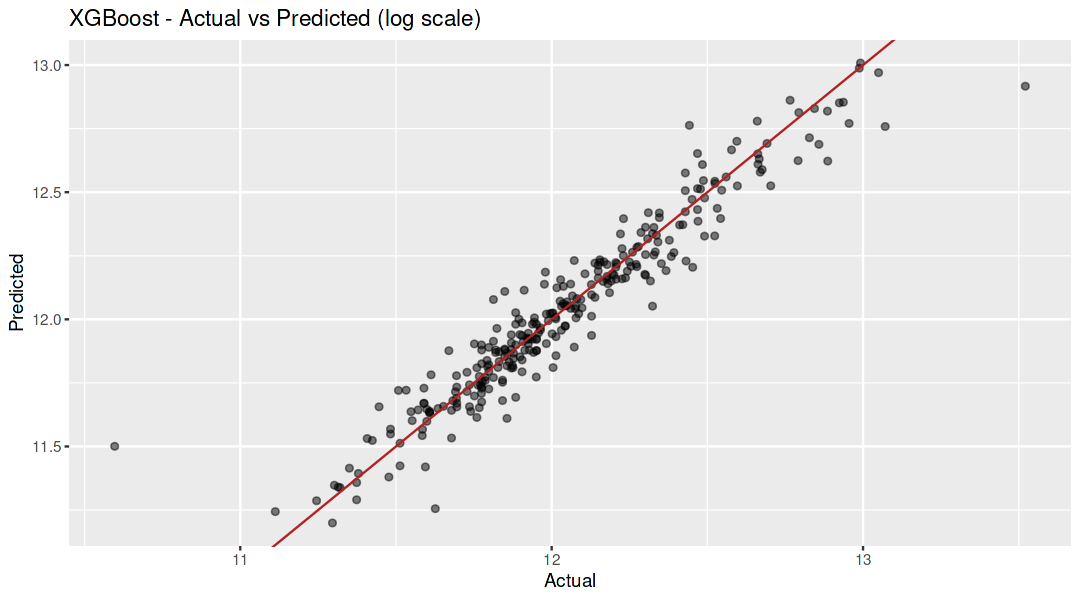

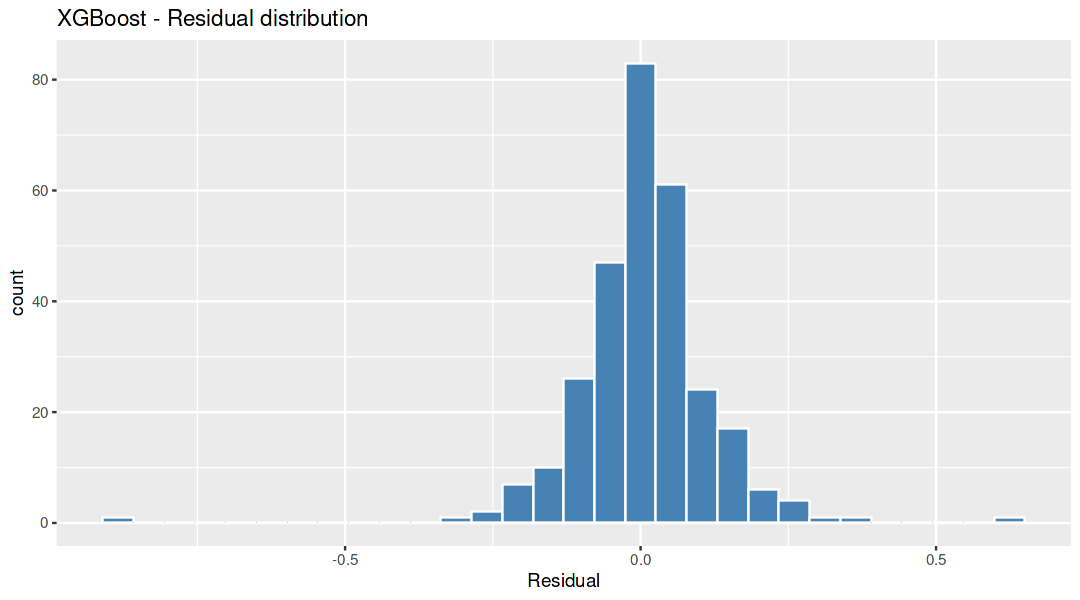

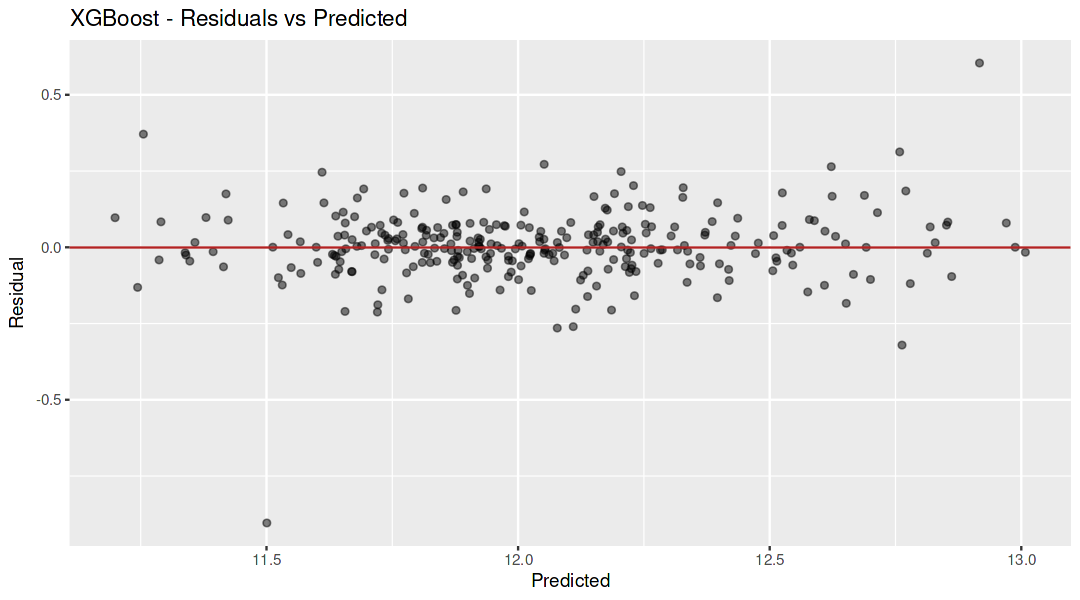

In [22]:
best <- results$Model[1]
d <- tibble(actual = y_te, pred = preds[[best]], resid = actual - pred)

print(ggplot(d, aes(actual, pred)) + geom_point(alpha = 0.5) +
  geom_abline(colour = "firebrick") +
  labs(title = paste(best, "- Actual vs Predicted (log scale)"), x = "Actual", y = "Predicted"))

print(ggplot(d, aes(resid)) +
  geom_histogram(bins = 30, fill = "steelblue", colour = "white") +
  labs(title = paste(best, "- Residual distribution"), x = "Residual"))

print(ggplot(d, aes(pred, resid)) + geom_point(alpha = 0.5) +
  geom_hline(yintercept = 0, colour = "firebrick") +
  labs(title = paste(best, "- Residuals vs Predicted"), x = "Predicted", y = "Residual"))

## 5. Explainable AI (SHAP on XGBoost)
SHAP values are in **log-price units**: a value of +0.1 means the feature raises the predicted price by about 10%.

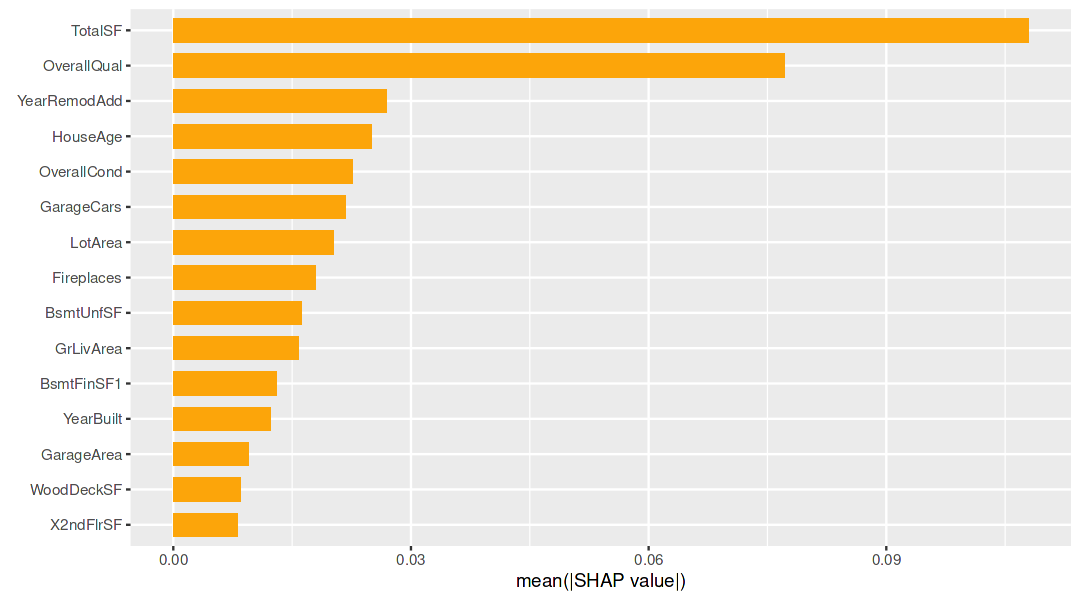

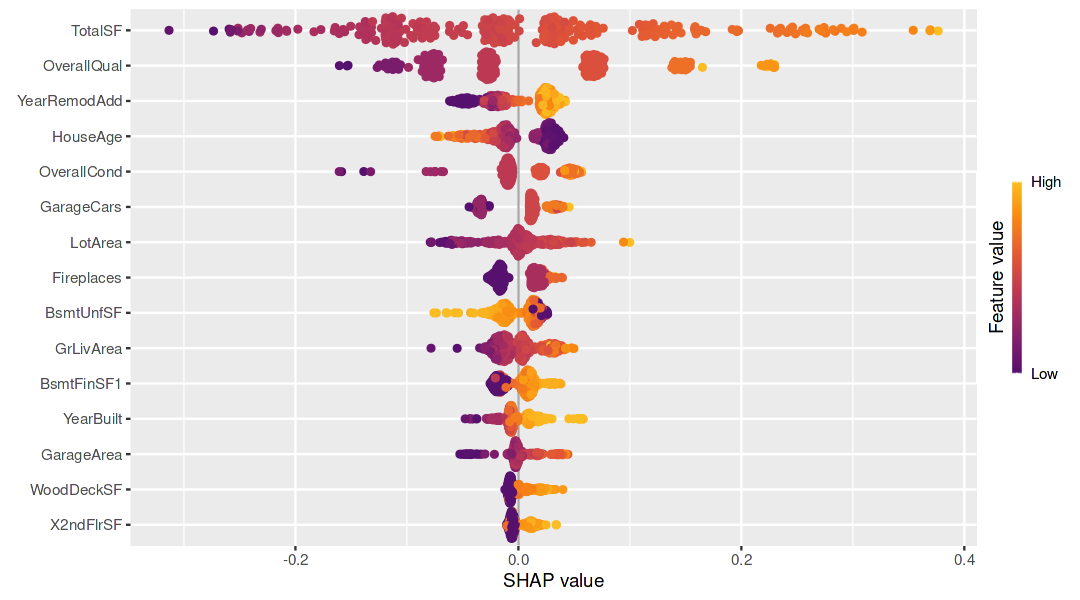

In [23]:
sv <- shapviz(xgb_model, X_pred = X_te, X = X_te)

print(sv_importance(sv, kind = "bar",      max_display = 15))   # global importance
print(sv_importance(sv, kind = "beeswarm", max_display = 15))   # beeswarm

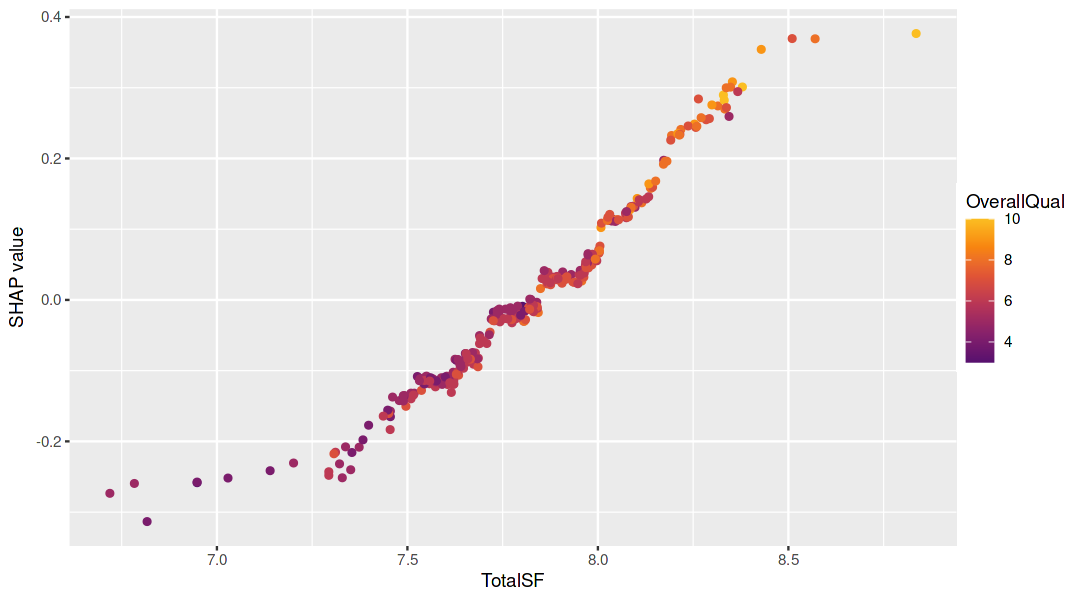

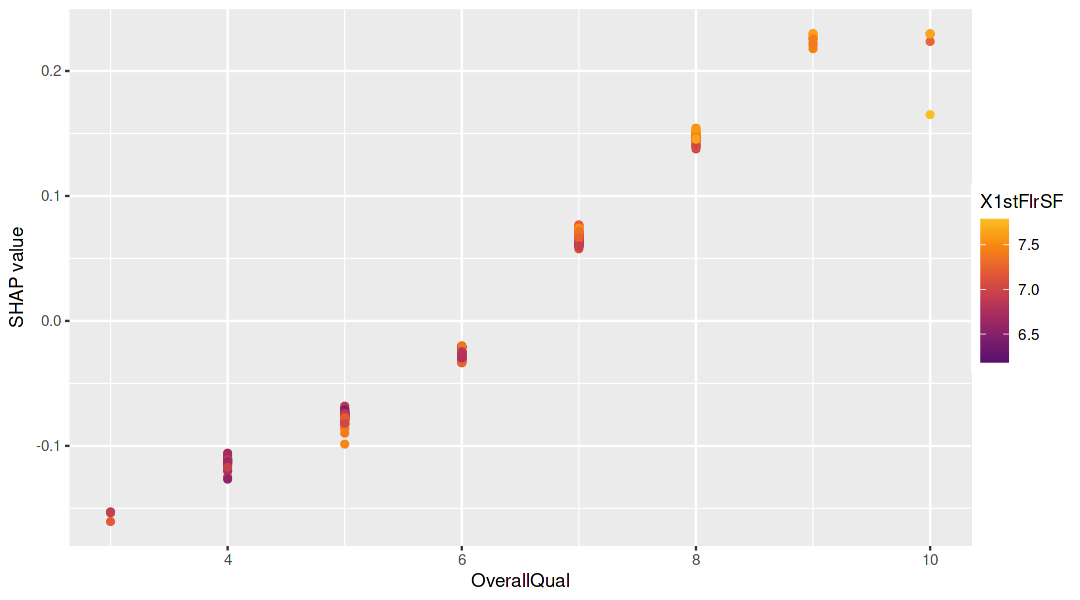

In [24]:
# Dependence plots for the two most important features
top2 <- names(sort(colMeans(abs(get_shap_values(sv))), decreasing = TRUE))[1:2]
for (v in top2) print(sv_dependence(sv, v = v))

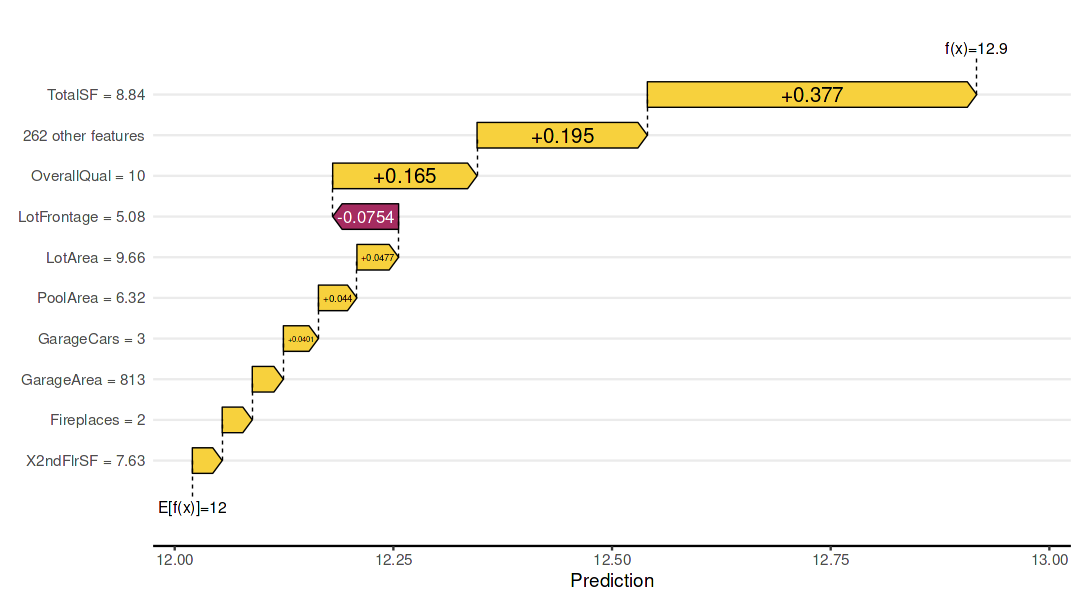

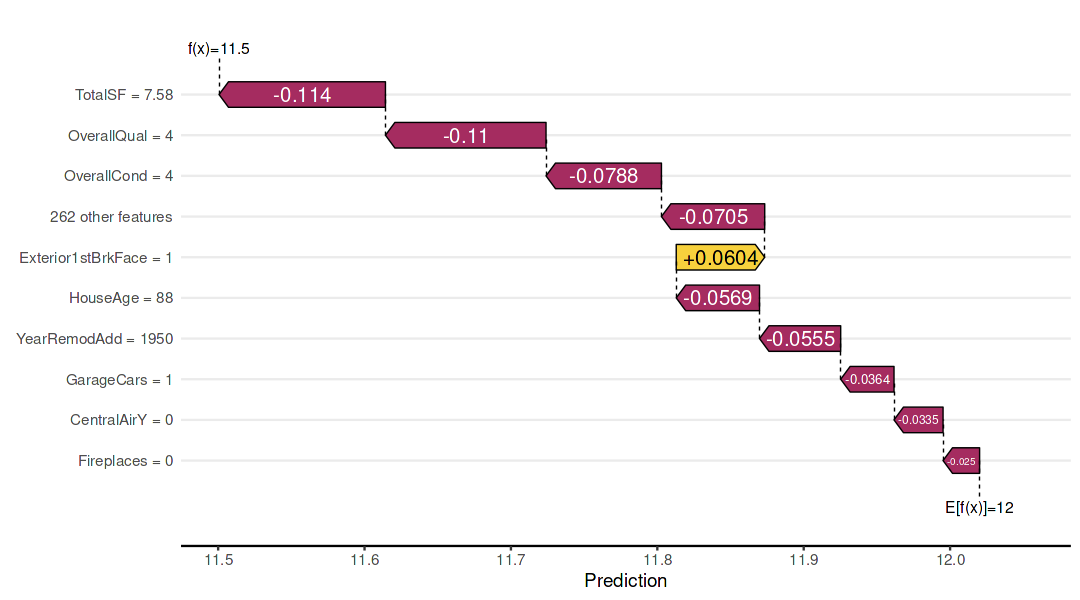

In [25]:
# Local explanations: most and least expensive house in the test split
print(sv_waterfall(sv, row_id = which.max(price_te)))
print(sv_waterfall(sv, row_id = which.min(price_te)))